In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/commonTools/")
#sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/PyTorch-VAE/")
import helper_functions as hf
import qRegNN_NFs_general as qrnn
import qRegNN_NFs_general_allInOne as qrnn2
import sklearn
import scipy
import sklearn.datasets as datasets
import h5py
import os
import pandas as pd
import corner
from sklearn.model_selection import train_test_split
sys.path.append("/home/sambt/SINF/")
sys.path.append("/home/sambt/SINF/sinf/")
from GIS import GIS
import torch
import torch.nn as nn
device = torch.device('cuda:0')
import uproot
from tqdm import tqdm

In [2]:
base = "/nobackup/users/sambt/QR_samples/LHCO/"
dirs = ["challenge/pythia_bkg/","challenge/BB1/","challenge/BB2/","challenge/BB3/",
        "rd/RD/","rd/ZXY/"]
dirs = [base+d for d in dirs]
for d in dirs:
    print(d.split("/")[-2])
    f_merge = d+"merged.h5"
    with h5py.File(f_merge,"r") as f:
        j1pt = f['jet1_pt'][()]
        j2pt = f['jet2_pt'][()]


    j1pt_r = []
    j2pt_r = []
    files = [f for f in os.listdir(d) if '.root' in f]
    order = []
    tbar = tqdm(range(len(files)))
    while len(order) < len(files):
        for f in files:
            if f in order:
                continue
            with uproot.open(d+f)['output'] as t:
                j1pt_r = t['jet1_pt'].array().to_numpy()
                j2pt_r = t['jet2_pt'].array().to_numpy()
                n = j1pt_r.shape[0]
            if np.all((j1pt_r == j1pt[:n]) & (j2pt_r == j2pt[:n])):
                order.append(f)
                if len(order) < len(files):
                    j1pt = j1pt[n:]
                    j2pt = j2pt[n:]
                tbar.update(1)
                tbar.refresh()
                break
    out_f = d+"root_order.txt"
    del tbar
    with open(out_f,"w") as fout:
        for k in order:
            fout.write(k+"\n")

pythia_bkg


  1%|          | 1/100 [00:00<00:30,  3.26it/s]

KeyboardInterrupt: 

In [3]:
base = "/nobackup/users/sambt/QR_samples/LHCO/"
f_pyth = f"{base}/challenge/pythia_bkg/merged.h5"
f_bb1 = f"{base}/challenge/BB1/merged.h5"
f_bb2 = f"{base}/challenge/BB2/merged.h5"
f_bb3 = f"{base}/challenge/BB3/merged.h5"

fitvars = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43',
           'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43']
    
with h5py.File(f_bb1,"r") as fp_b1:
    labels_b1 = np.loadtxt(f"{base}/challenge/BB1/events_LHCO2020_BlackBox1.masterkey")
    b1 = np.concatenate([fp_b1[v][()][labels_b1==0].reshape(-1,1) for v in fitvars],axis=1)
    
with h5py.File(f_bb2,"r") as fp_b2:
    b2 = np.concatenate([fp_b2[v][()].reshape(-1,1) for v in fitvars],axis=1)
    
with h5py.File(f_bb3,"r") as fp_b3:
    labels_b3 = np.loadtxt(f"{base}/challenge/BB3/events_LHCO2020_BlackBox3.masterkey")
    b3 = np.concatenate([fp_b3[v][()][labels_b3==0].reshape(-1,1) for v in fitvars],axis=1)

with h5py.File(f_pyth,"r") as fp:
    pyth = np.concatenate([fp[v][()].reshape(-1,1) for v in fitvars],axis=1)

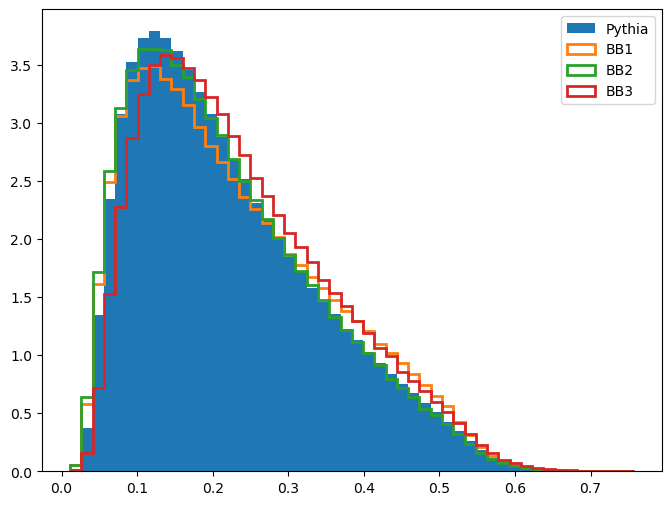

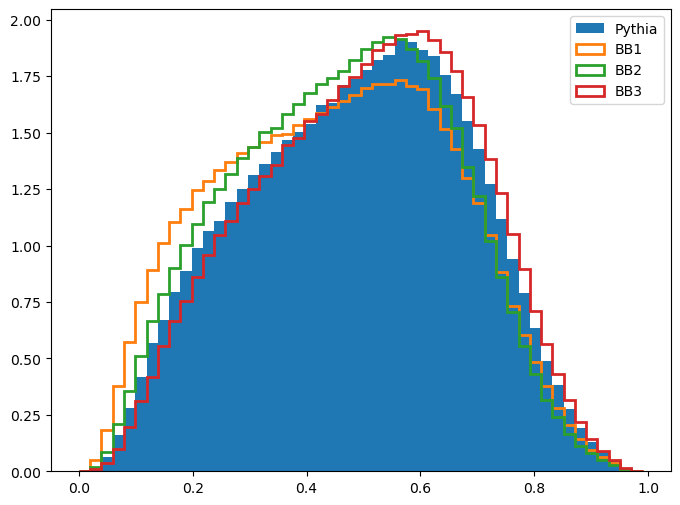

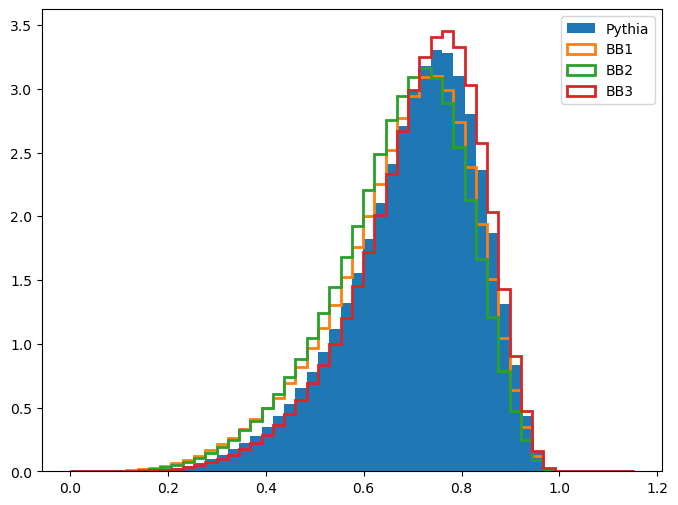

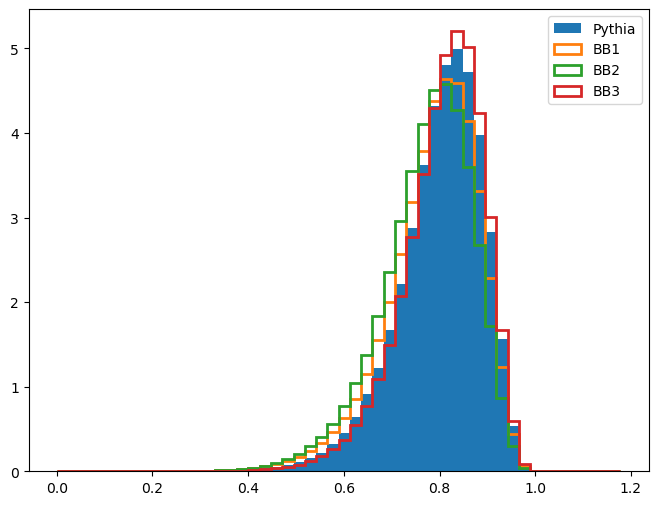

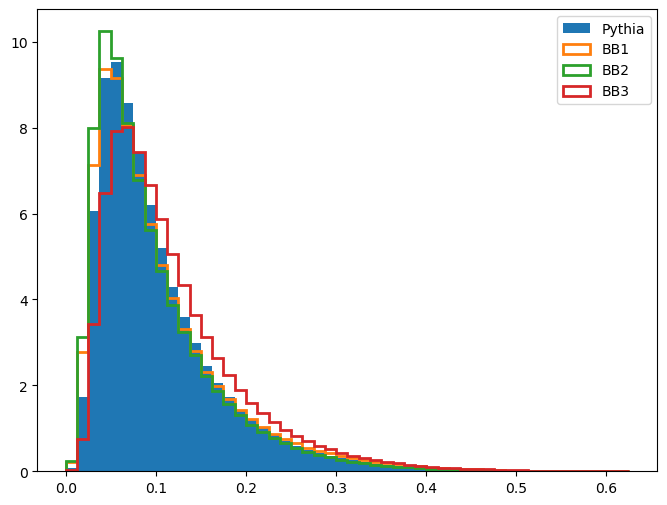

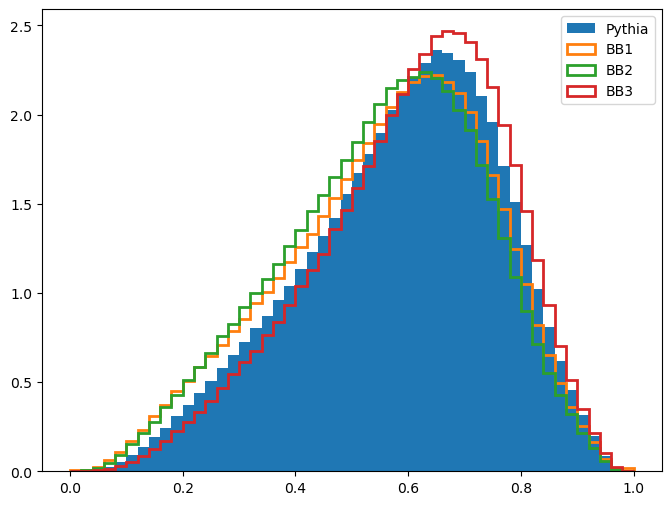

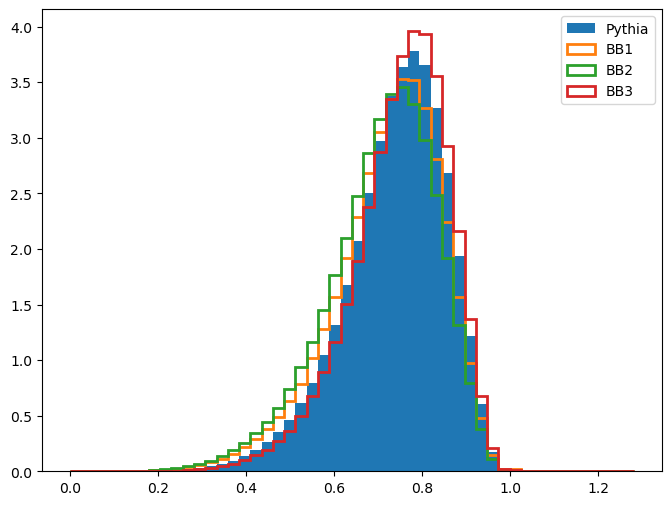

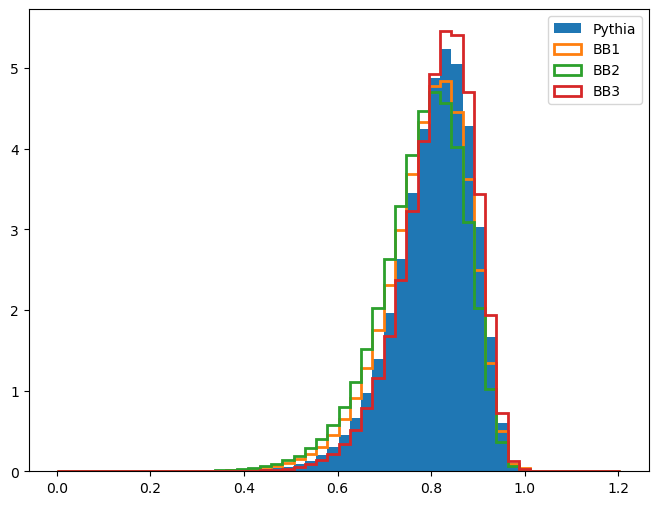

In [9]:
for i in range(pyth.shape[1]):
    plt.figure(figsize=(8,6))
    h,bins,_ = plt.hist(pyth[:,i],bins=50,density=True,histtype='stepfilled',label="Pythia")
    h,bins,_ = plt.hist(b1[:,i],bins=bins,density=True,histtype='step',label="BB1",linewidth=2)
    h,bins,_ = plt.hist(b2[:,i],bins=bins,density=True,histtype='step',label="BB2",linewidth=2)
    h,bins,_ = plt.hist(b3[:,i],bins=bins,density=True,histtype='step',label="BB3",linewidth=2)
    plt.legend()

In [2]:
base = "/nobackup/users/sambt/QR_samples/LHCO/"
f_pyth = f"{base}/challenge/pythia_bkg/merged.h5"
f_ind_pyth = f"{base}/challenge/pythia_bkg/split_indices.h5"
f_bb1 = f"{base}/challenge/BB1/merged.h5"
f_ind_bb1 = f"{base}/challenge/BB1/split_indices.h5"
f_rd = f"{base}/rd/RD/merged.h5"
f_zxy = f"{base}/rd/ZXY/merged.h5"

fitvars = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43',
           'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43']

with h5py.File(f_ind_pyth,'r') as f:
    pyth_test_idx = f['test_inds'][()]
    pyth_val_idx = f['val_inds'][()]
    
with h5py.File(f_ind_bb1,'r') as f:
    bb1_test_idx = f['test_inds'][()]
    bb1_val_idx = f['val_inds'][()]
    
with h5py.File(f_bb1,"r") as fp_b1:
    labels_b1 = np.loadtxt(f"{base}/challenge/BB1/events_LHCO2020_BlackBox1.masterkey")
    b1_test = np.concatenate([fp_b1[v][()][labels_b1==0].reshape(-1,1) for v in fitvars],axis=1)[bb1_test_idx]
    b1_val = np.concatenate([fp_b1[v][()][labels_b1==0].reshape(-1,1) for v in fitvars],axis=1)[bb1_val_idx]

b1 = np.concatenate((b1_test,b1_val),axis=0)

with h5py.File(f_pyth,"r") as fp:
    pyth_test = np.concatenate([fp[v][()].reshape(-1,1) for v in fitvars],axis=1)[pyth_test_idx]
    pyth_val = np.concatenate([fp[v][()].reshape(-1,1) for v in fitvars],axis=1)[pyth_val_idx]
    
pyth = np.concatenate((pyth_test,pyth_val),axis=0)
    
with h5py.File(f_rd,"r") as frd:
    label = frd['label'][()]
    mask = label==0
    rd = np.concatenate([frd[v][()][mask].reshape(-1,1) for v in fitvars],axis=1)
    rd_sig = np.concatenate([frd[v][()][~mask].reshape(-1,1) for v in fitvars],axis=1)
    
with h5py.File(f_zxy,"r") as fz:
    zx = np.concatenate([fz[v][()].reshape(-1,1) for v in fitvars],axis=1)

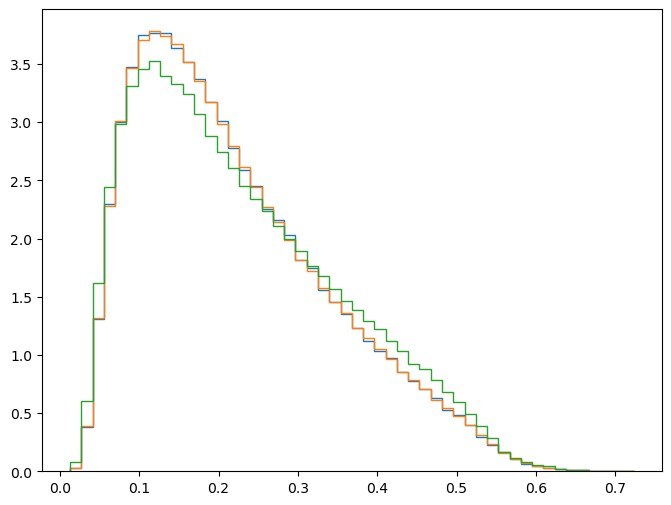

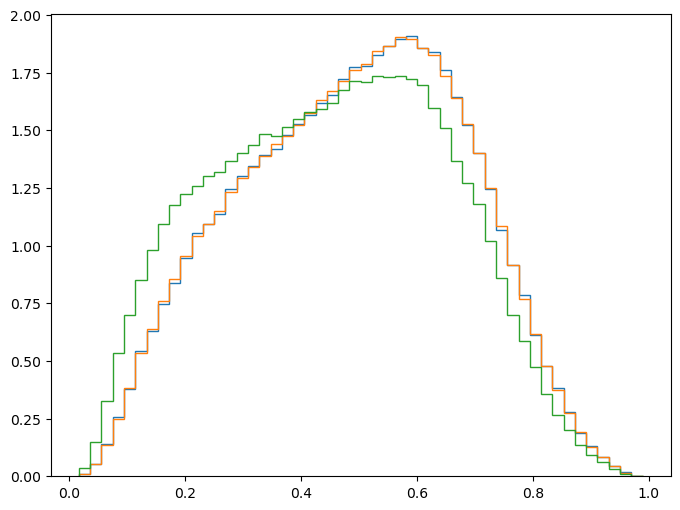

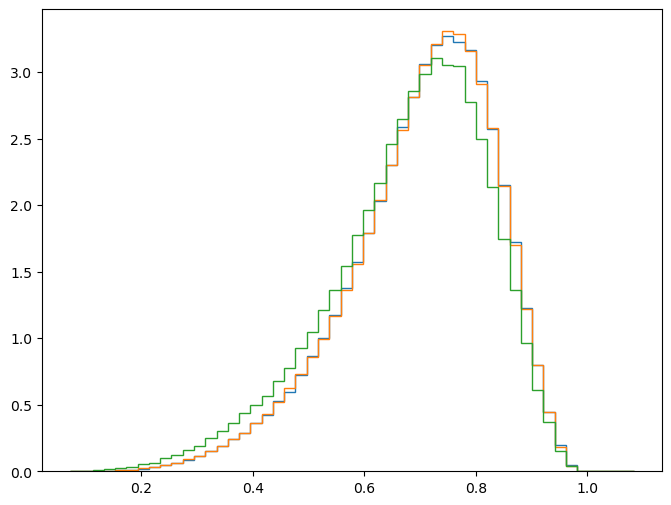

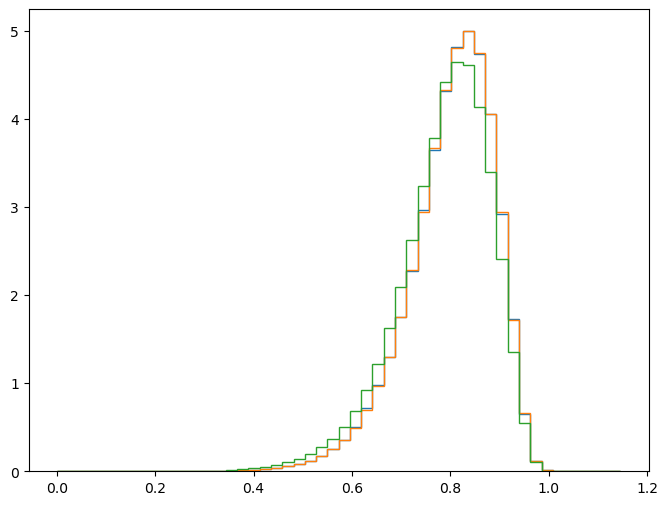

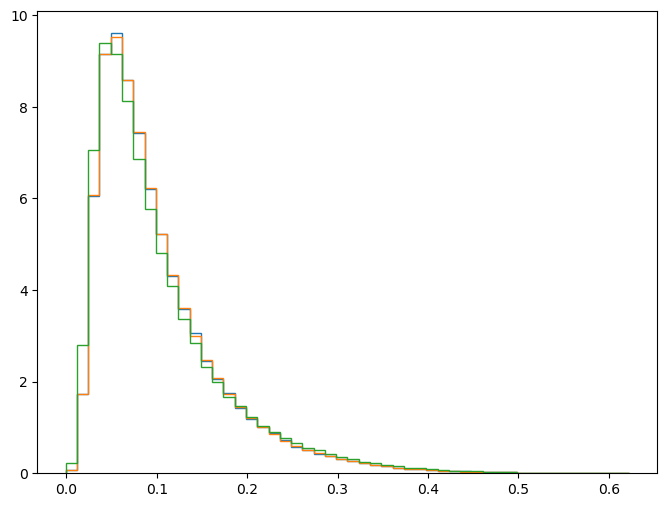

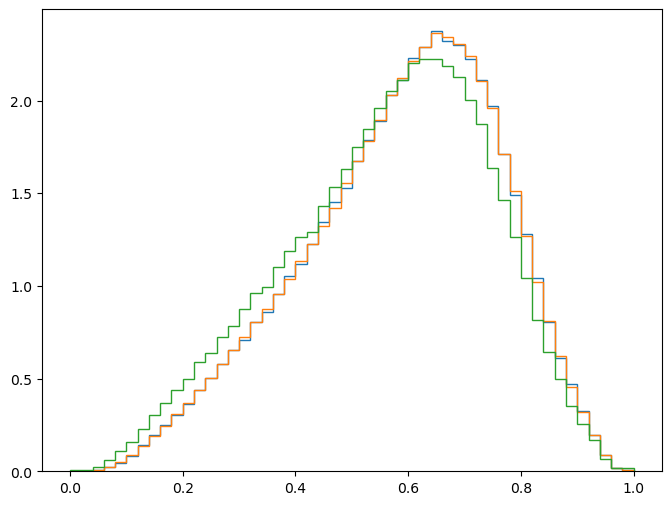

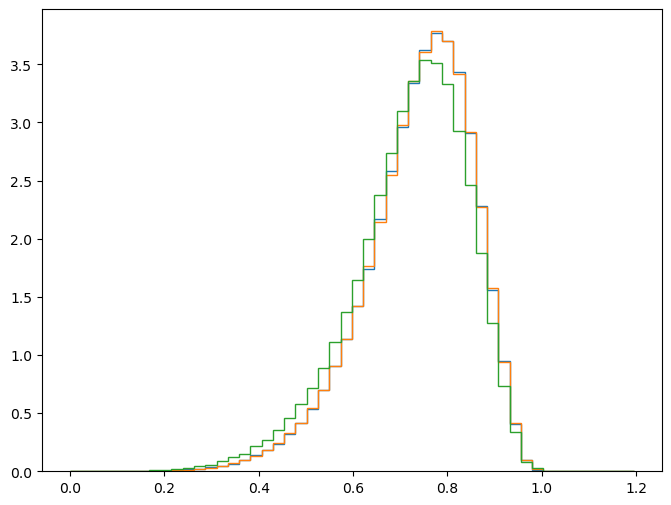

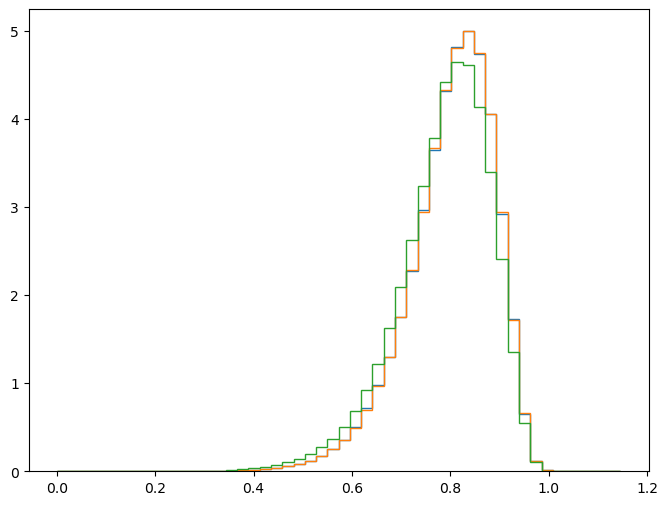

In [3]:
for i in range(pyth_test.shape[1]):
    plt.figure(figsize=(8,6))
    h1,bins,_ = plt.hist(pyth_test[:,i],bins=50,density=True,histtype='step')
    h2,bins,_ = plt.hist(rd[:,i],bins=bins,density=True,histtype='step')
    h3,bins,_ = plt.hist(b1_test[:,i],bins=bins,density=True,histtype='step')
    #h4,bins,_ = plt.hist(rd_sig[:,i],bins=bins,density=True,histtype='step')
    #h5,bins,_ = plt.hist(zx[:,i],bins=bins,density=True,histtype='step')
    #qrnn.plotPair(pyth[:,i],rd[:,i])

In [3]:
model_dir = "LHCO_PythSim_to_PythBB1_jets12_v2"
corrector = qrnn.chainedNFCorrector(f"NF_models_QR_general/{model_dir}/")

In [4]:
corr_b1 = corrector.invertFull(b1)
corr_b1 = np.concatenate([corr_b1[v] for v in fitvars],axis=1)

[0, 1, 2, 3, 4, 5, 6]


100%|██████████| 50/50 [00:01<00:00, 48.19it/s]


[0, 1, 2, 3, 4, 5]


100%|██████████| 50/50 [00:00<00:00, 68.23it/s]


[0, 1, 2, 3, 4]


...

100%|██████████| 50/50 [00:00<00:00, 82.50it/s]


[0]


100%|██████████| 50/50 [00:00<00:00, 70.99it/s]


[]


100%|██████████| 50/50 [00:00<00:00, 60.03it/s]


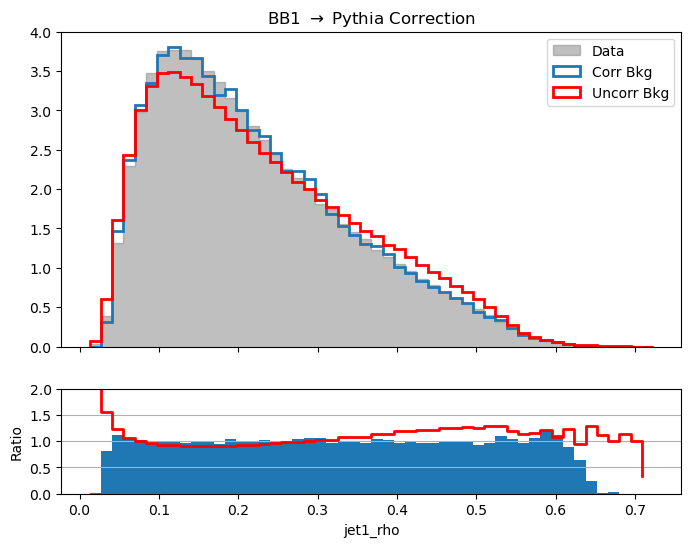

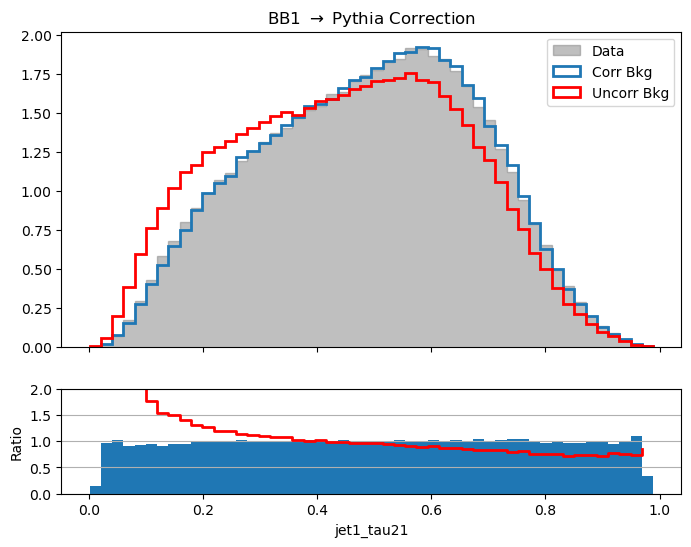

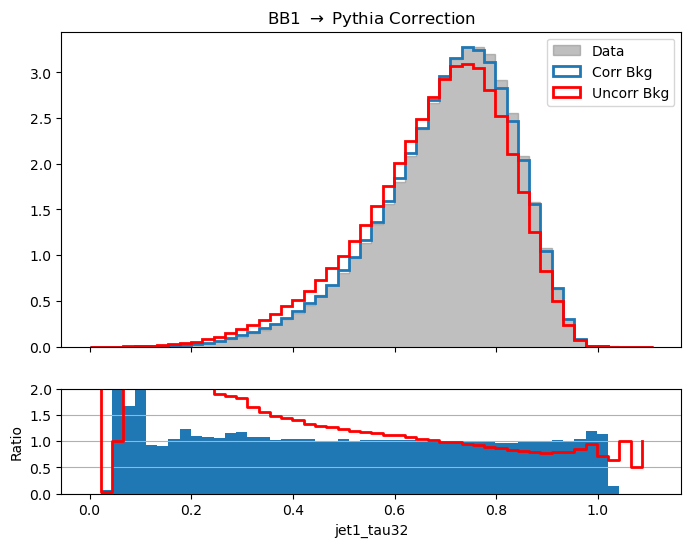

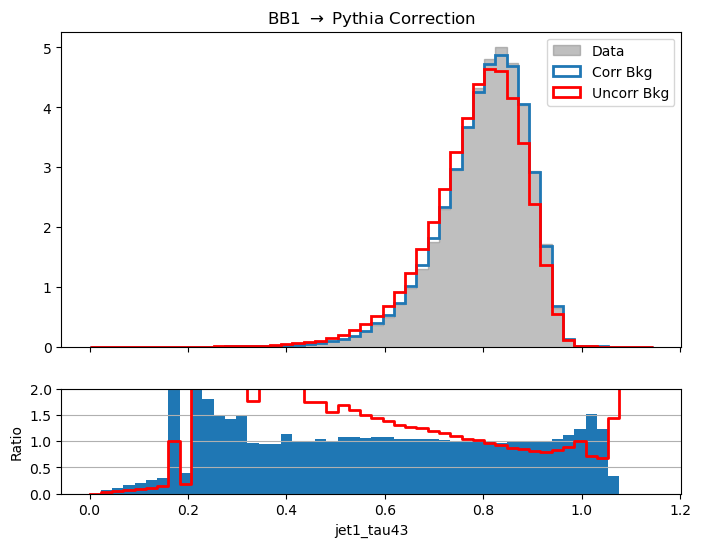

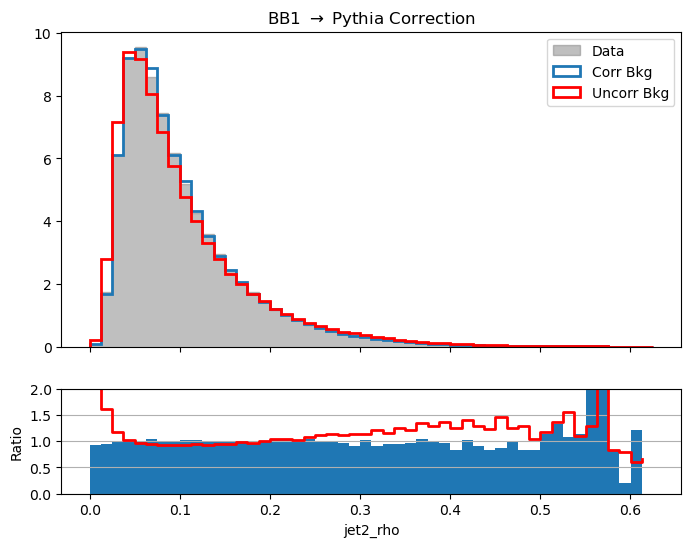

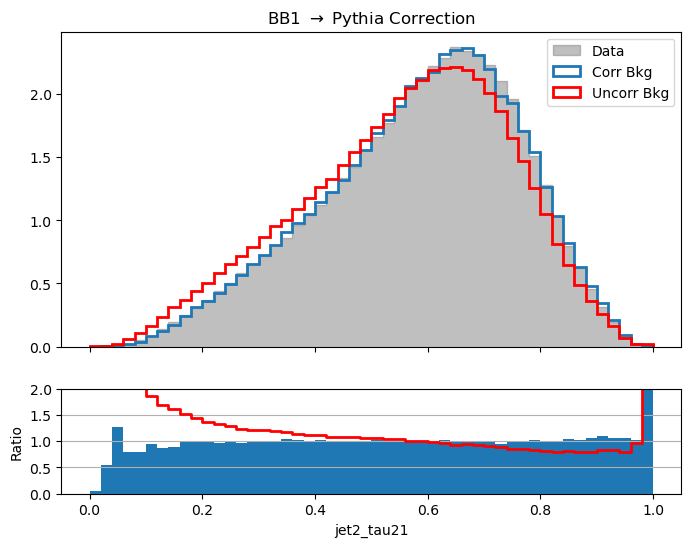

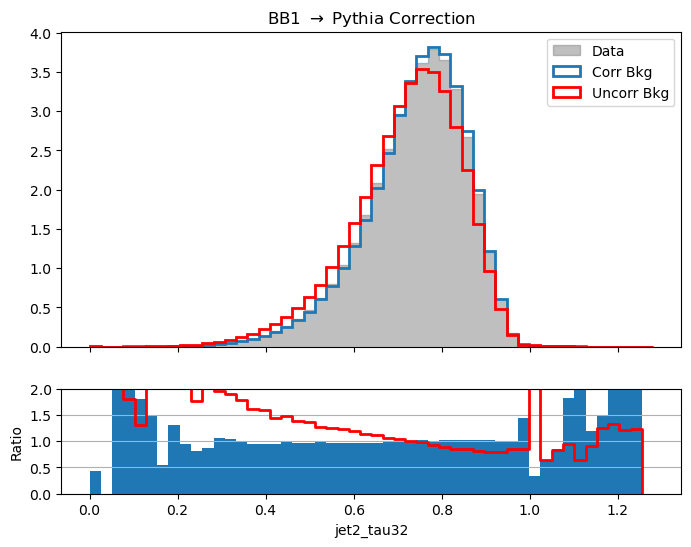

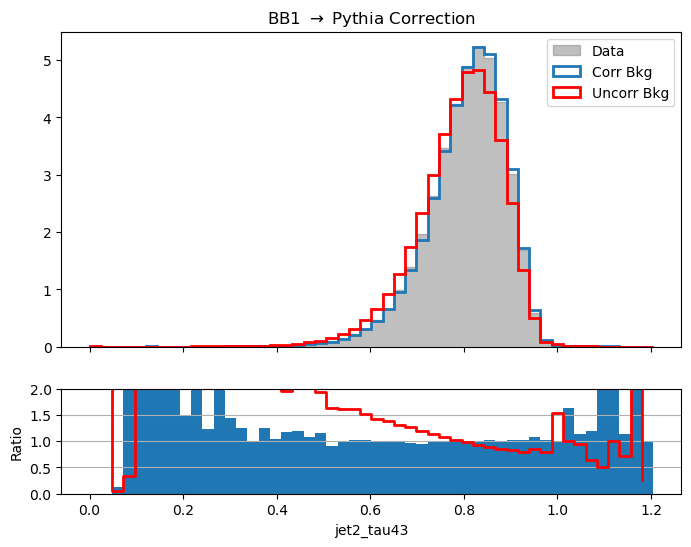

In [5]:
for i in range(len(fitvars)):
    qrnn.plotTriplet(pyth[:,i],corr_b1[:,i],b1[:,i],50,fitvars[i],r"BB1 $\rightarrow$ Pythia Correction","",save=False,log=False,ylim=[0,2])

# Train signal vs BB1 NN, test on pythia and on BB1

In [6]:
rd_sig_train,rd_sig_test = train_test_split(rd_sig,train_size=0.5)
rd_sig_test,rd_sig_val = train_test_split(rd_sig_test,train_size=0.5)

pyth_train,pyth_test = train_test_split(pyth,train_size=0.5)
pyth_test,pyth_val = train_test_split(pyth_test,train_size=0.5)

b1_train_idx, b1_test_idx = train_test_split(np.arange(b1.shape[0]),train_size=0.5)
b1_test_idx, b1_val_idx = train_test_split(b1_test_idx,train_size=0.5)
b1_train, b1_test, b1_val = b1[b1_train_idx], b1[b1_test_idx], b1[b1_val_idx]
corr_b1_train, corr_b1_test, corr_b1_val = corr_b1[b1_train_idx], corr_b1[b1_test_idx], corr_b1[b1_val_idx]

###

train = np.concatenate((b1_train,rd_sig_train),axis=0)
train_lab = np.concatenate((np.zeros((b1_train.shape[0],1)),np.ones((rd_sig_train.shape[0],1))),axis=0)
perm = np.random.permutation(train.shape[0])
train = train[perm]
train_lab = train_lab[perm]

val = np.concatenate((b1_val,rd_sig_val),axis=0)
val_lab = np.concatenate((np.zeros((b1_val.shape[0],1)),np.ones((rd_sig_val.shape[0],1))),axis=0)
perm = np.random.permutation(val.shape[0])
val = val[perm]
val_lab = val_lab[perm]

test = np.concatenate((b1_test,rd_sig_test),axis=0)
test_lab = np.concatenate((np.zeros((b1_test.shape[0],1)),np.ones((rd_sig_test.shape[0],1))),axis=0)
perm = np.random.permutation(test.shape[0])
test = test[perm]
test_lab = test_lab[perm]

test_pyth = np.concatenate((pyth_test,rd_sig_test),axis=0)
test_lab_pyth = np.concatenate((np.zeros((pyth_test.shape[0],1)),np.ones((rd_sig_test.shape[0],1))),axis=0)
perm = np.random.permutation(test_pyth.shape[0])
test_pyth = test_pyth[perm]
test_lab_pyth = test_lab_pyth[perm]

val_pyth = np.concatenate((pyth_val,rd_sig_val),axis=0)
val_lab_pyth = np.concatenate((np.zeros((pyth_val.shape[0],1)),np.ones((rd_sig_val.shape[0],1))),axis=0)
perm = np.random.permutation(val_pyth.shape[0])
val_pyth = val_pyth[perm]
val_lab_pyth = val_lab_pyth[perm]

train_pyth = np.concatenate((pyth_train,rd_sig_train),axis=0)
train_lab_pyth = np.concatenate((np.zeros((pyth_train.shape[0],1)),np.ones((rd_sig_train.shape[0],1))),axis=0)
perm = np.random.permutation(train_pyth.shape[0])
train_pyth = train_pyth[perm]
train_lab_pyth = train_lab_pyth[perm]

test_corr_b1 = np.concatenate((corr_b1_test,rd_sig_test),axis=0)
test_lab_corr_b1 = np.concatenate((np.zeros((corr_b1_test.shape[0],1)),np.ones((rd_sig_test.shape[0],1))),axis=0)
perm = np.random.permutation(test_corr_b1.shape[0])
test_corr_b1 = test_corr_b1[perm]
test_lab_corr_b1 = test_lab_corr_b1[perm]

mean,sd = train_pyth.mean(axis=0), train_pyth.std(axis=0)

train = (train-mean)/sd
test = (test-mean)/sd
val = (val-mean)/sd
test_pyth = (test_pyth-mean)/sd
train_pyth = (train_pyth-mean)/sd
val_pyth = (val_pyth-mean)/sd
test_corr_b1 = (test_corr_b1-mean)/sd

Loss: 0.22893309593200684, p = 138: 100%|██████████| 2927/2927 [00:54<00:00, 53.29it/s]


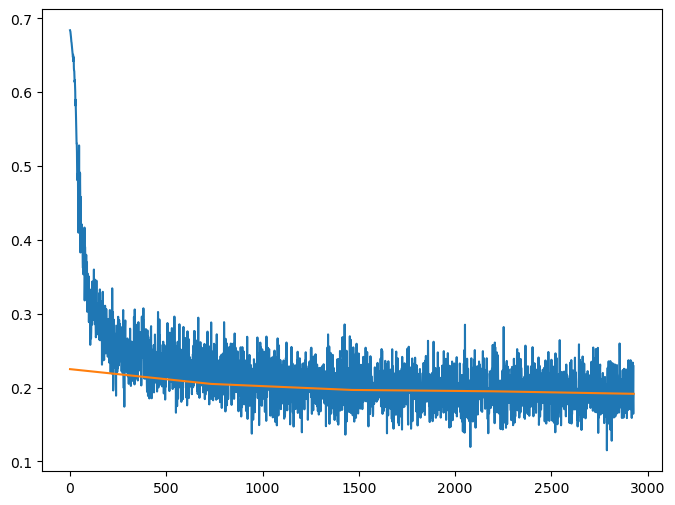

In [7]:
n_in = train.shape[1]
n_hidden = 64
num_hidden = 6
n_out = 1
act = nn.ReLU()
out_act = nn.Sigmoid()

net1 = qrnn.NeuralNet(n_in, n_hidden, n_out, num_hidden, act=act, out_act=out_act, dropout=0.1)
#net1 = qrnn.train_nn(net1,train_pyth,train_lab_pyth,val_pyth,val_lab_pyth,n_epoch=5,lr=5e-4,bs=512,lossfunc="BCE")
net1 = qrnn.train_nn(net1,train,train_lab,val,val_lab,n_epoch=5,lr=5e-4,bs=512,lossfunc="BCE")

In [8]:
#torch.save(net1,f"NF_models_QR_general/{model_dir}/NN_pyth_vs_rdSig.pt")
torch.save(net1,f"NF_models_QR_general/{model_dir}/NN_bb1_vs_rdSig.pt")

In [9]:
#net1 = torch.load(f"NF_models_QR_general/{model_dir}/NN_pyth_vs_rdSig.pt")
net1 = torch.load(f"NF_models_QR_general/{model_dir}/NN_bb1_vs_rdSig.pt")

Text(0, 0.5, 'True Negative Rate')

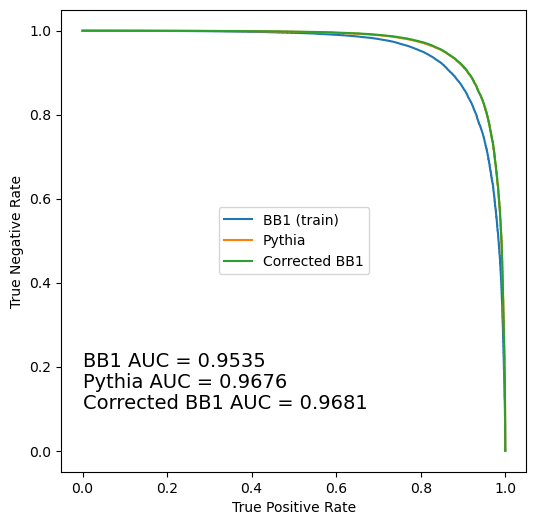

In [10]:
# roc curve
net1 = net1.to(device)
with torch.no_grad():
    preds = net1(torch.tensor(test,device=device,dtype=torch.float32)).cpu().numpy()
    preds_pyth = net1(torch.tensor(test_pyth,device=device,dtype=torch.float32)).cpu().numpy()
    preds_corr_b1 = net1(torch.tensor(test_corr_b1,device=device,dtype=torch.float32)).cpu().numpy()

from sklearn.metrics import roc_auc_score, roc_curve

fpr,tpr,thresh = roc_curve(test_lab,preds)
auc = roc_auc_score(test_lab,preds)

fpr_pyth,tpr_pyth,thresh_pyth = roc_curve(test_lab_pyth,preds_pyth)
auc_pyth = roc_auc_score(test_lab_pyth,preds_pyth)

fpr_corr_b1,tpr_corr_b1,thresh_corr_b1 = roc_curve(test_lab_corr_b1,preds_corr_b1)
auc_corr_b1 = roc_auc_score(test_lab_corr_b1,preds_corr_b1)

plt.figure(figsize=(6,6))
plt.plot(tpr,1-fpr,label=r'BB1 (train)')
plt.plot(tpr_pyth,1-fpr_pyth,label=r'Pythia')
plt.plot(tpr_corr_b1,1-fpr_corr_b1,label="Corrected BB1")
plt.text(0.0,0.2,f"BB1 AUC = {auc:.4f}",fontsize=14)
plt.text(0.0,0.15,f"Pythia AUC = {auc_pyth:.4f}",fontsize=14)
plt.text(0.0,0.1,f"Corrected BB1 AUC = {auc_corr_b1:.4f}",fontsize=14)
plt.legend(loc='center')
plt.xlabel("True Positive Rate")
plt.ylabel("True Negative Rate")

Text(0, 0.5, 'SIC')

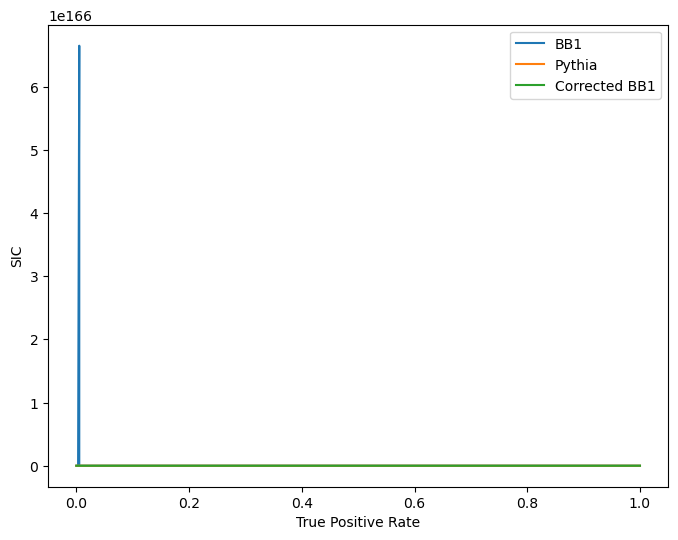

In [11]:
# SIC curves
sic = np.divide(tpr,np.sqrt(fpr),where=fpr>0)
sic_pyth = np.divide(tpr_pyth,np.sqrt(fpr_pyth),where=fpr_pyth>0)
sic_corr_b1 = np.divide(tpr_corr_b1,np.sqrt(fpr_corr_b1),where=fpr_corr_b1>0)

plt.figure(figsize=(8,6))
plt.plot(tpr,sic,label="BB1")
plt.plot(tpr_pyth,sic_pyth,label="Pythia")
plt.plot(tpr_corr_b1,sic_corr_b1,label="Corrected BB1")
plt.legend()
plt.xlabel("True Positive Rate")
plt.ylabel("SIC")

# Try training VAE

In [6]:
rd_sig_train,rd_sig_test = train_test_split(rd_sig,train_size=0.5)
rd_sig_test,rd_sig_val = train_test_split(rd_sig_test,train_size=0.5)

pyth_train,pyth_test = train_test_split(pyth,train_size=0.5)
pyth_test,pyth_val = train_test_split(pyth_test,train_size=0.5)

b1_train_idx, b1_test_idx = train_test_split(np.arange(b1.shape[0]),train_size=0.5)
b1_test_idx, b1_val_idx = train_test_split(b1_test_idx,train_size=0.5)
b1_train, b1_test, b1_val = b1[b1_train_idx], b1[b1_test_idx], b1[b1_val_idx]
corr_b1_train, corr_b1_test, corr_b1_val = corr_b1[b1_train_idx], corr_b1[b1_test_idx], corr_b1[b1_val_idx]

###

train = b1_train

val = b1_val

test = b1_test

test_pyth = pyth_test

val_pyth = pyth_val

train_pyth = pyth_train

test_corr_b1 = corr_b1_test

mean,sd = train.mean(axis=0), train.std(axis=0)

train = (train-mean)/sd
test = (test-mean)/sd
val = (val-mean)/sd
test_pyth = (test_pyth-mean)/sd
train_pyth = (train_pyth-mean)/sd
val_pyth = (val_pyth-mean)/sd
test_corr_b1 = (test_corr_b1-mean)/sd

In [7]:
import torch
import torch.nn as nn
import torch.utils.data as utils
device = torch.device('cuda:0')
torch.set_default_tensor_type('torch.cuda.FloatTensor')
from vae import VAE, InfiniteLoader, trainVAE

In [8]:
vae = VAE(8,[16,32,64,128],128).to(device)
dataset = utils.TensorDataset(torch.tensor(train,dtype=torch.float32,device=device))
loader = InfiniteLoader(dataset=dataset,batch_size=1024,shuffle=True,generator=torch.Generator(device='cuda'))
vae, losses = trainVAE(vae,loader,epochs=4000)

Loss: 0.4893915355205536: 100%|██████████| 4000/4000 [01:16<00:00, 51.95it/s] 


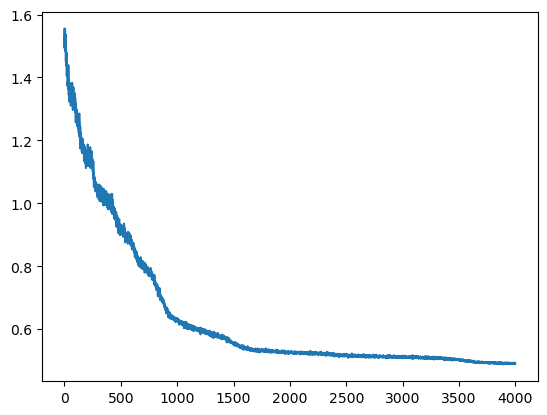

In [9]:
plt.plot(np.arange(len(losses)),losses)

In [10]:
with torch.no_grad():
    out_test = vae(torch.tensor(test,device=device,dtype=torch.float32)).detach().cpu().numpy()
    out_test_pyth = vae(torch.tensor(test_pyth,device=device,dtype=torch.float32)).detach().cpu().numpy()

In [11]:
def mse(x,y):
    return np.sqrt(np.sum((x-y)**2,axis=1))
loss_test = mse(test,out_test)
loss_test_pyth = mse(test_pyth,out_test_pyth)

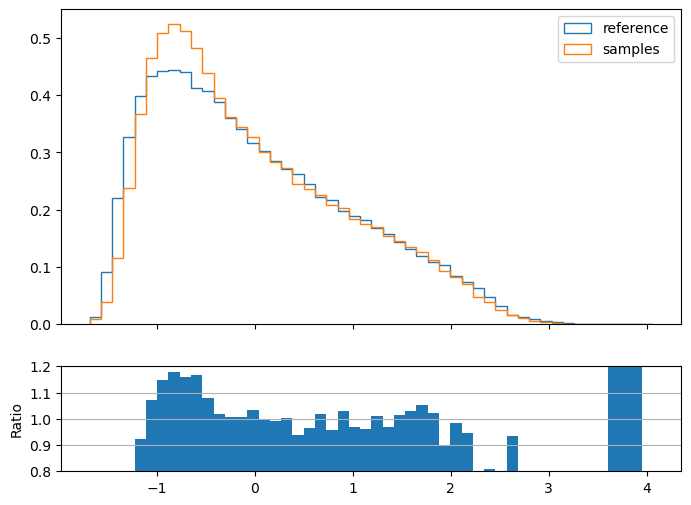

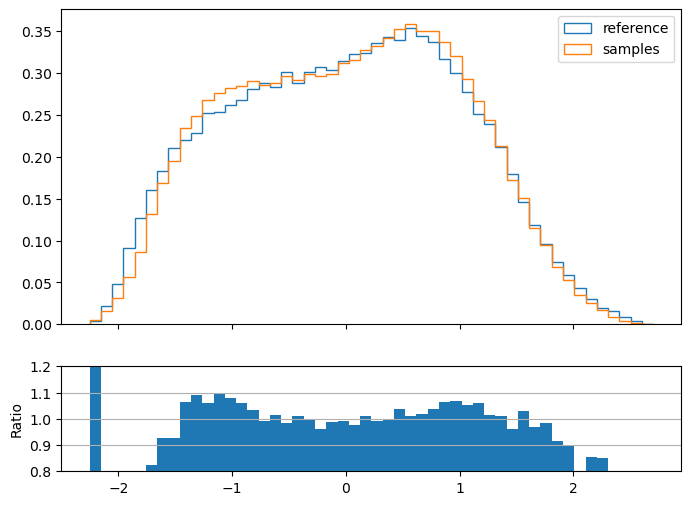

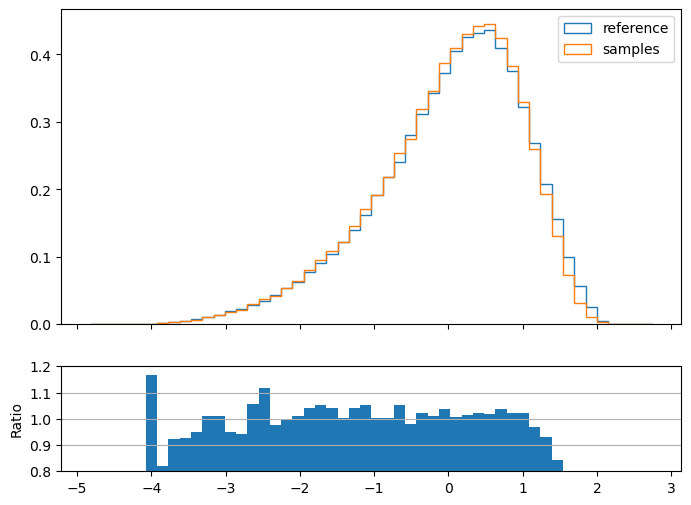

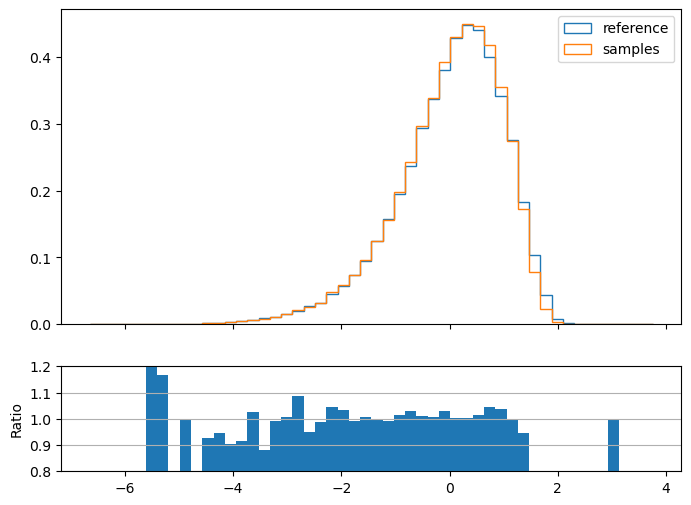

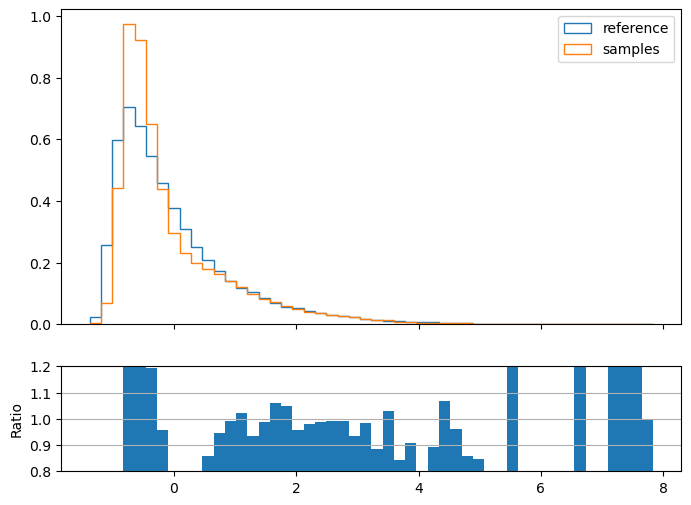

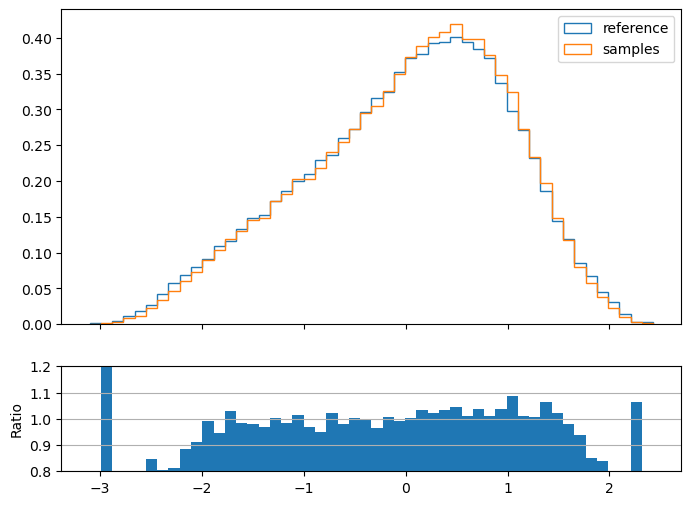

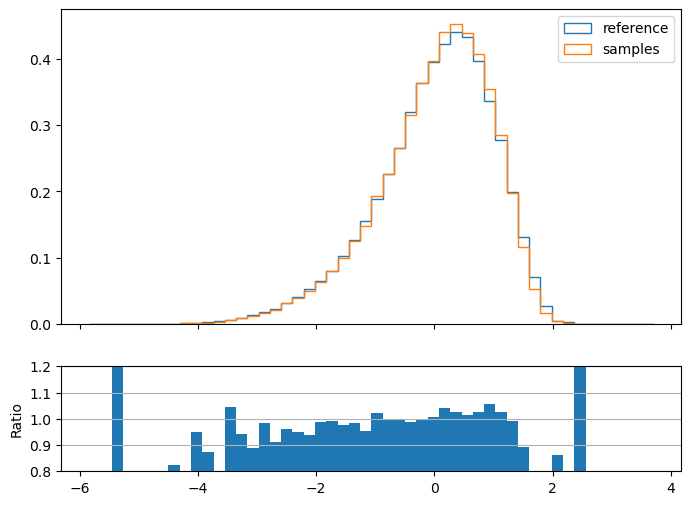

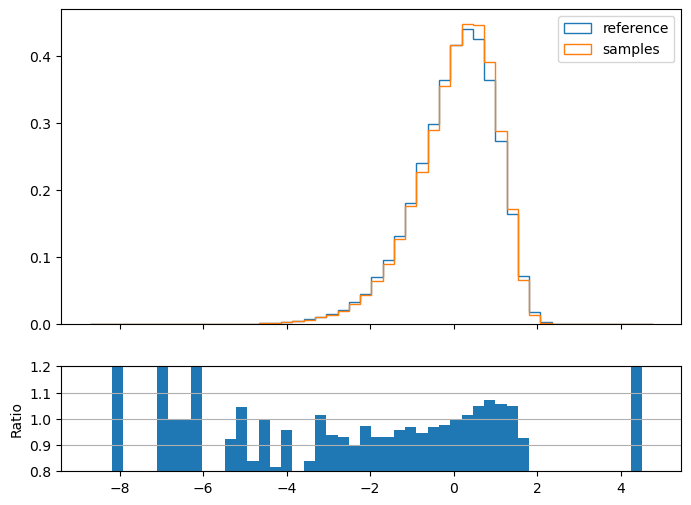

In [12]:
for i in range(pyth_test.shape[1]):
    qrnn.plotPair(test[:,i],out_test[:,i])

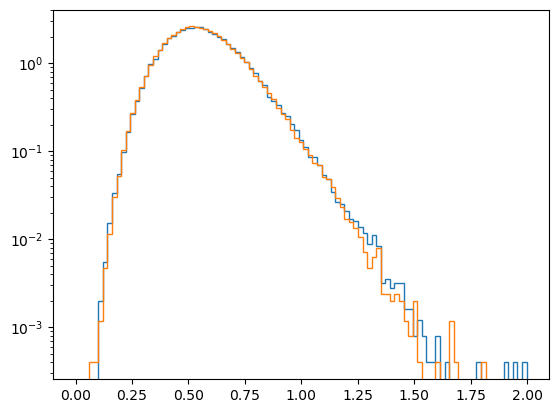

In [13]:
bins = np.linspace(0,max(loss_test.max(),loss_test_pyth.max()),100)
h1,bins,_ = plt.hist(loss_test,bins=bins,density=True,histtype='step')
h2,bins,_ = plt.hist(loss_test_pyth,bins=bins,density=True,histtype='step')
plt.yscale('log')

In [14]:
print(np.mean(loss_test))
print(np.mean(loss_test_pyth))

0.5692538948342927
0.5661346561005294
